In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
code_dir = f'{os.getenv('HOME')}/cai-dr2-clustering-products/clustering_statistics/'
sys.path.insert(0,code_dir)
import tools
import plotting_tools

In [3]:
plot_dir = Path('_plots')
plot_dir.mkdir(exist_ok=True)
ext = 'png'

In [4]:
# !ls /dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/Uchuu-SHAM/altmtl0/loa-v1/mock0/LSScats/

In [5]:
# !ls /global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base/glam-uchuu-v2-altmtl/mock150/

In [6]:
!tree -d -L 3 $tools.base_stats_dir | grep -vE '(complete)'

/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics
├── auxiliary_data
├── bao
│   └── base
├── full_shape
│   ├── base
│   │   ├── abacus-2ndgen-dr2-altmtl
│   │   ├── abacus-hf-dr2-v2-altmtl
│   │   ├── glam-uchuu-v1-altmtl
│   │   ├── glam-uchuu-v2-altmtl
│   │   ├── holi-v1-altmtl
│   │   ├── holi-v3-altmtl
│   │   └── uchuu-hf-altmtl
│   └── data_splits
│       ├── abacus-hf-dr2-v2-altmtl
│       ├── blinded_data
│       ├── glam-uchuu-v2-altmtl
│       └── holi-v3-altmtl
├── local_png
│   └── base
│       ├── glam-uchuu-v1-altmtl
│       └── holi-v3-altmtl
└── merged_catalogs
    └── glam-uchuu-v1-altmtl

75 directories


In [7]:
analysis = 'full_shape'
project = f'{analysis}/base'
region  = 'GCcomb'
tracers = ['LRG', 'ELG_LOPnotqso', 'QSO']

stats_dir = Path(str(tools.base_stats_dir).replace('global','dvs_ro'))

ells4pk = (0,2)
ells4xi = [0,2,4]
ells4bk = ((0,0,0), (2,0,2))

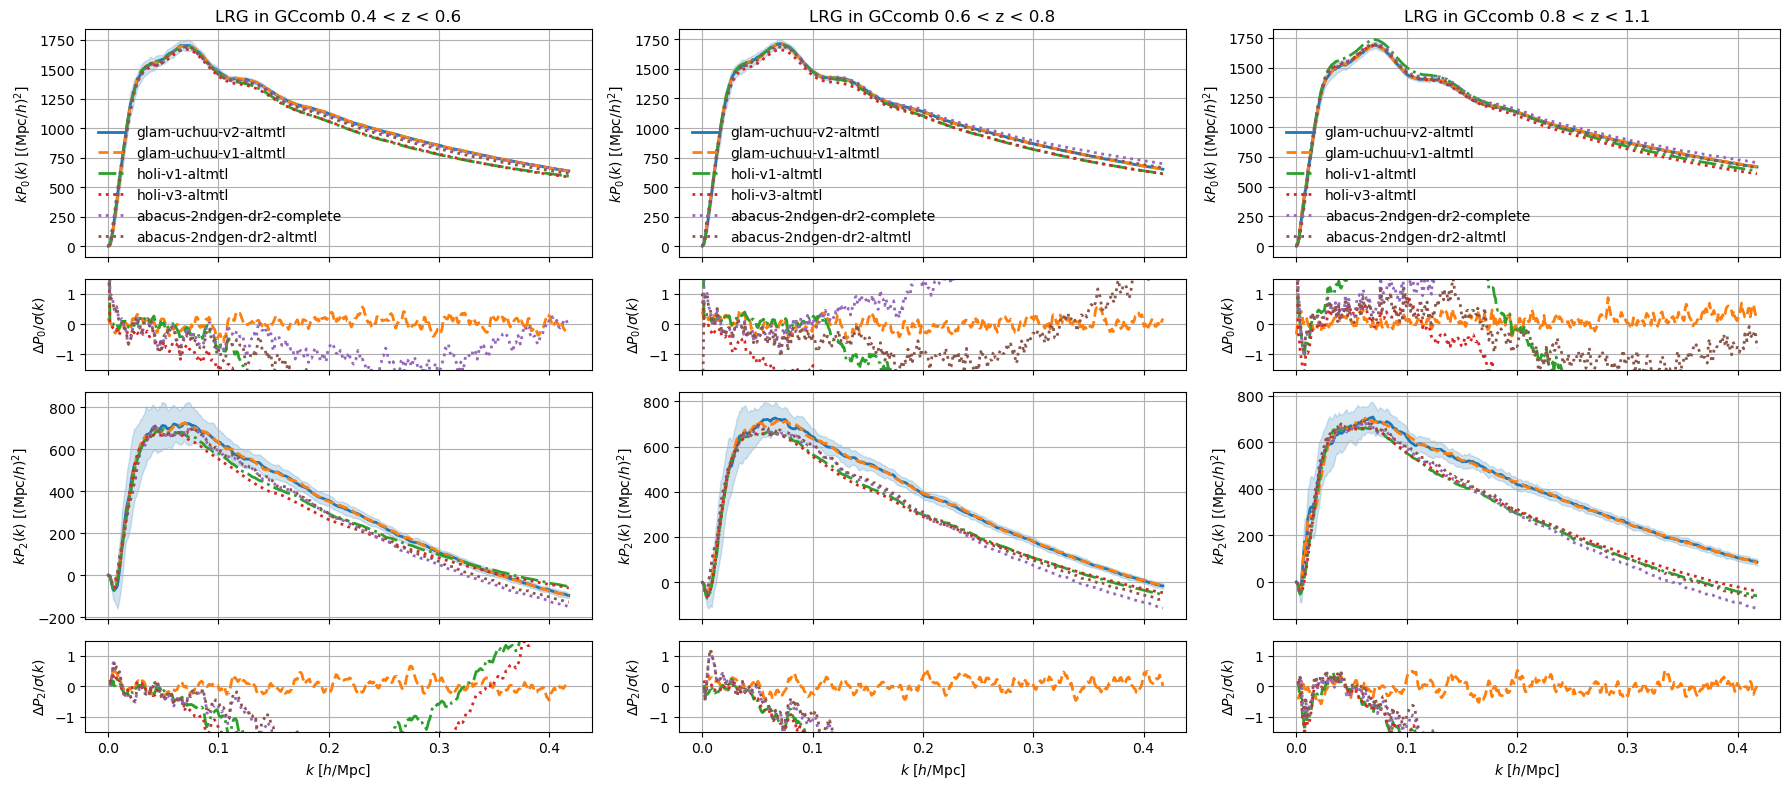

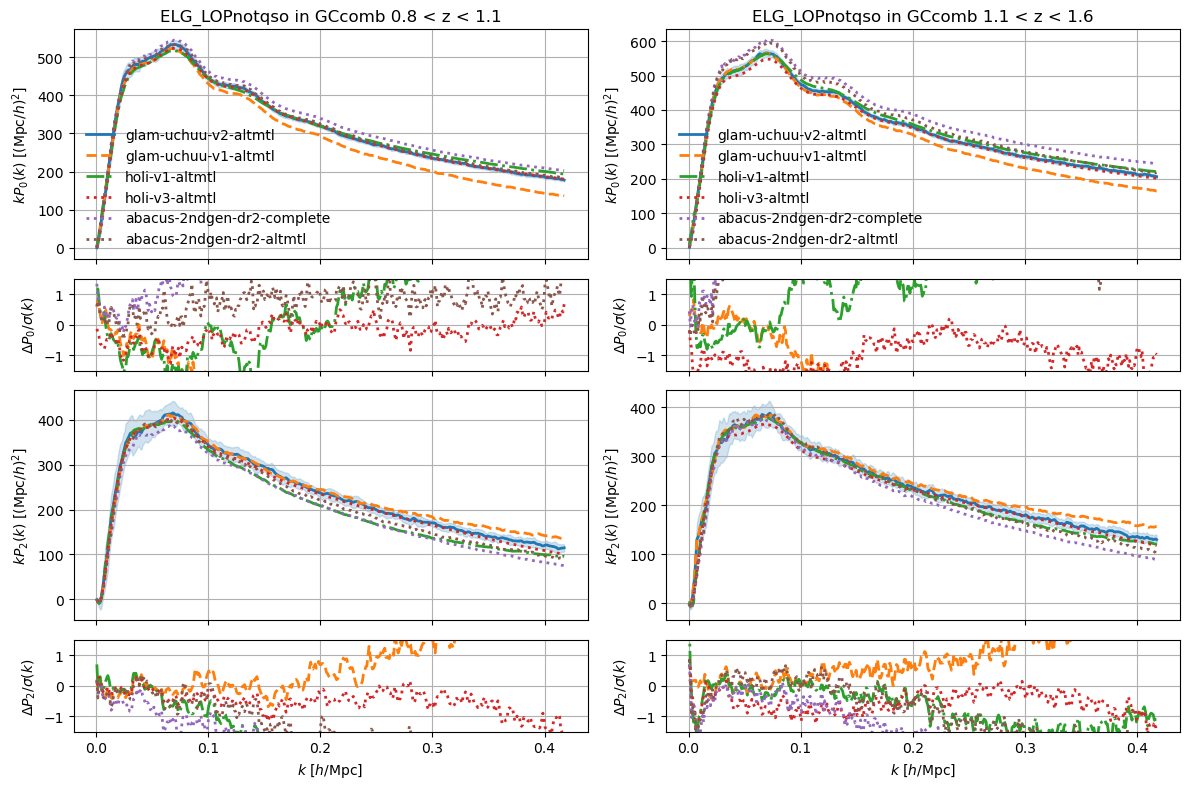

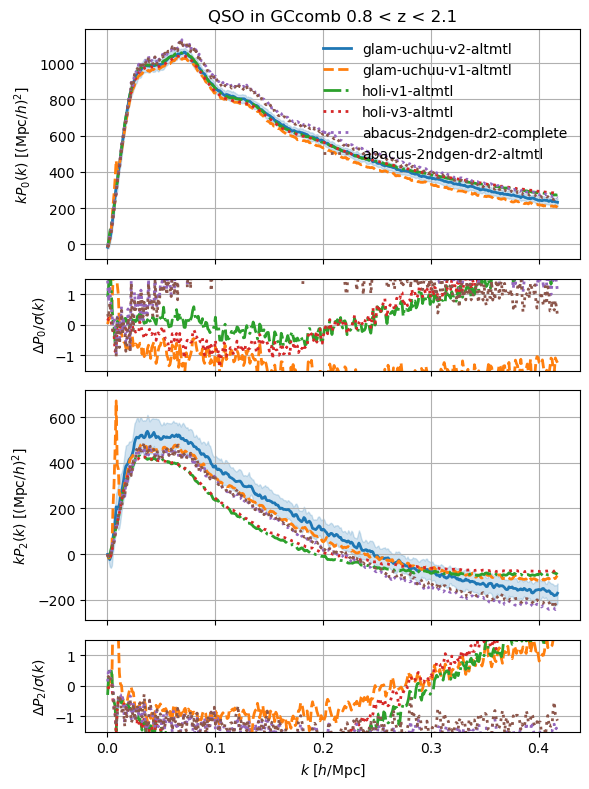

In [12]:
reference = 'glam-uchuu-v2-altmtl'
cases = {'glam-uchuu-v2-altmtl':   {'version': 'glam-uchuu-v2-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False},
         'glam-uchuu-v1-altmtl':   {'version': 'glam-uchuu-v1-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False},
         'holi-v1-altmtl':   {'version': 'holi-v1-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False},
         'holi-v3-altmtl':   {'version': 'holi-v3-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False},
         'abacus-2ndgen-dr2-complete':   {'version': 'abacus-2ndgen-dr2-complete', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False},
         'abacus-2ndgen-dr2-altmtl':   {'version': 'abacus-2ndgen-dr2-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False}}
         # 'abacus-hf-dr2-v2-altmtl':   {'version': 'abacus-hf-dr2-v2-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False}}
         # 'uchuu-hf-altmtl':   {'version': 'uchuu-hf-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False},

scaling='kpk'
# scaling='loglog'
colors = dict(zip(cases, [f'C{i}' for i in range(len(cases))]))
linestyles = dict(zip(cases, ['-', '--','-.',':',':',':',':']))
plot_kws = dict(colors=colors,linestyles=linestyles,scaling=scaling,stats_dir=stats_dir,project=project)

for tracer in tracers:
    zranges = tools.propose_fiducial('zranges',tracer,analysis=analysis)
    nrows  = len(ells4pk) * 2
    ncols  = len(zranges)
    figure = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * len(ells4pk)), sharex='col', gridspec_kw={'height_ratios': [2.5, 1] * len(ells4pk)})
    for iz, zrange in enumerate(zranges):    
        plot_kws = plot_kws|dict(reference=reference, figure=figure, ax_col=iz, ells=ells4pk)
        plotting_tools.plot_stats('mesh2_spectrum', cases, tracer, zrange, region, **plot_kws)
    plt.tight_layout()
    basename = f'checks_pk_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}.{ext}'
    figure[0].savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
    plt.show()
    print()

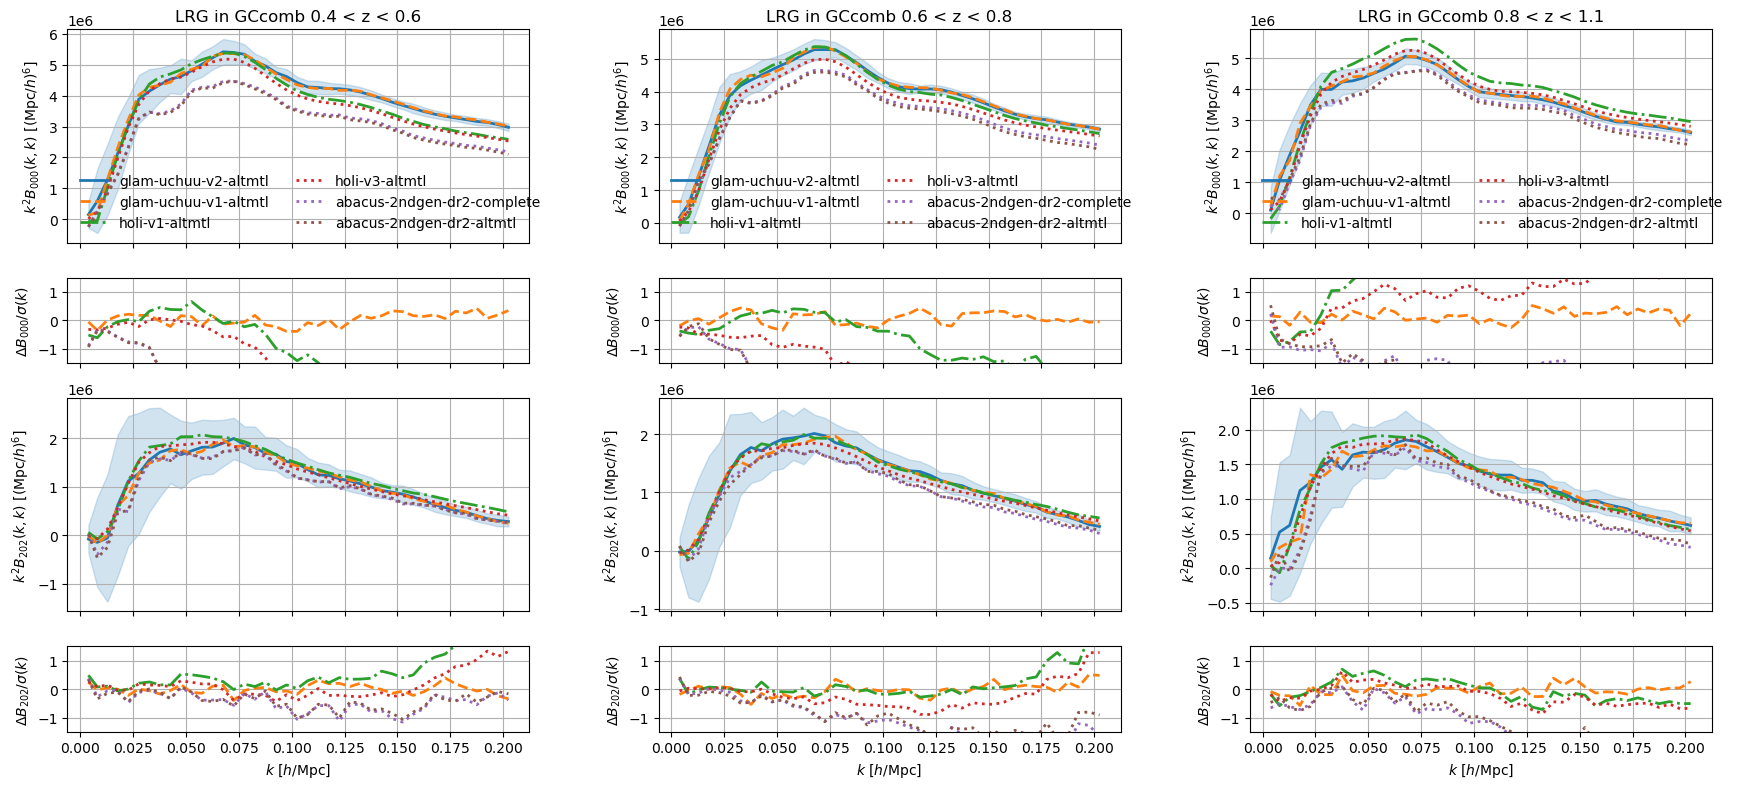

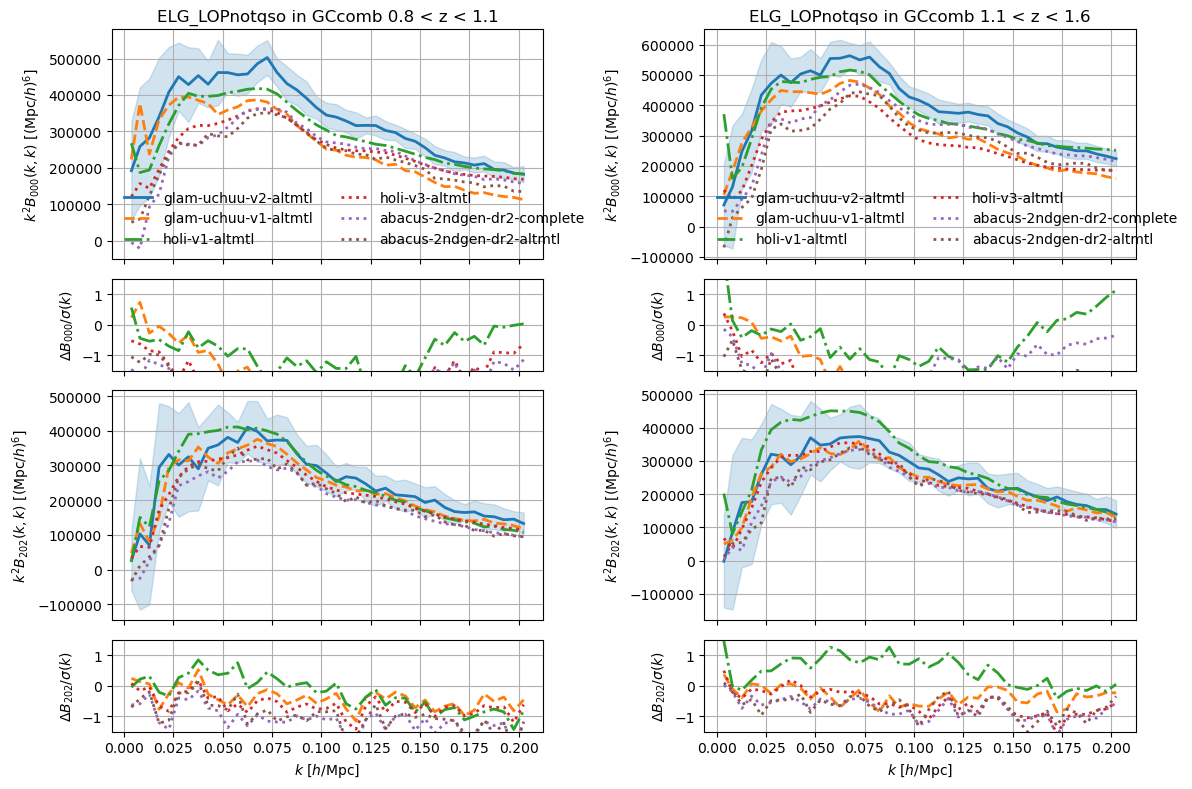

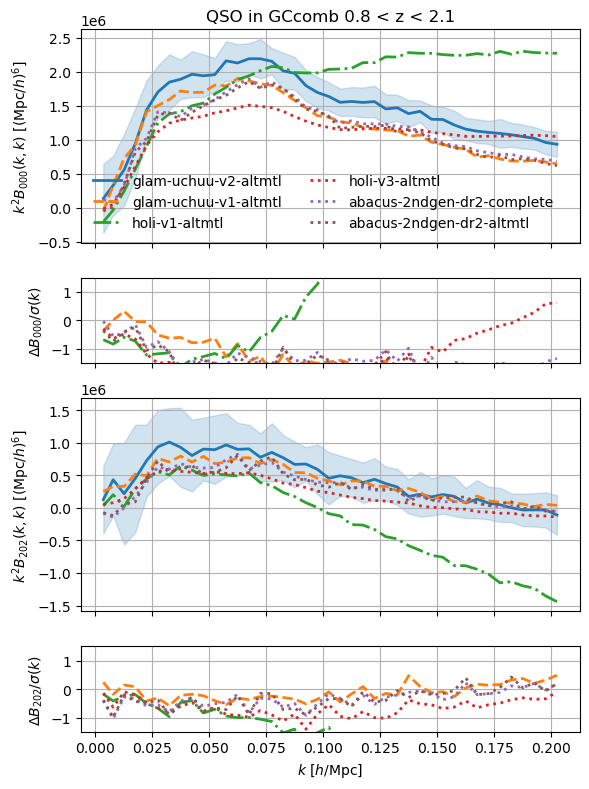

In [9]:
reference = 'glam-uchuu-v2-altmtl'
cases = {'glam-uchuu-v2-altmtl':   {'version': 'glam-uchuu-v2-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False},
         'glam-uchuu-v1-altmtl':   {'version': 'glam-uchuu-v1-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False},
         'holi-v1-altmtl':   {'version': 'holi-v1-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False},
         'holi-v3-altmtl':   {'version': 'holi-v3-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False},
         'abacus-2ndgen-dr2-complete':   {'version': 'abacus-2ndgen-dr2-complete', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False},
         'abacus-2ndgen-dr2-altmtl':   {'version': 'abacus-2ndgen-dr2-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False}}

scaling='kpk'
# scaling='loglog'
colors = dict(zip(cases, [f'C{i}' for i in range(len(cases))]))
linestyles = dict(zip(cases, ['-', '--','-.',':',':',':']))
plot_kws = dict(colors=colors,linestyles=linestyles,scaling=scaling,stats_dir=stats_dir,project=project)

for tracer in tracers:
    zranges = tools.propose_fiducial('zranges',tracer,analysis=analysis)
    nrows  = len(ells4bk) * 2
    ncols  = len(zranges)
    figure = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * len(ells4bk)), sharex='col', gridspec_kw={'height_ratios': [2.5, 1] * len(ells4bk)})
    for iz, zrange in enumerate(zranges):    
        plot_kws = plot_kws|dict(reference=reference, figure=figure, ax_col=iz, ells=ells4bk)
        plotting_tools.plot_stats('mesh3_spectrum_sugiyama-diagonal', cases, tracer, zrange, region, **plot_kws)
    plt.tight_layout()
    basename = f'checks_bk_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}.{ext}'
    figure[0].savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
    plt.show()

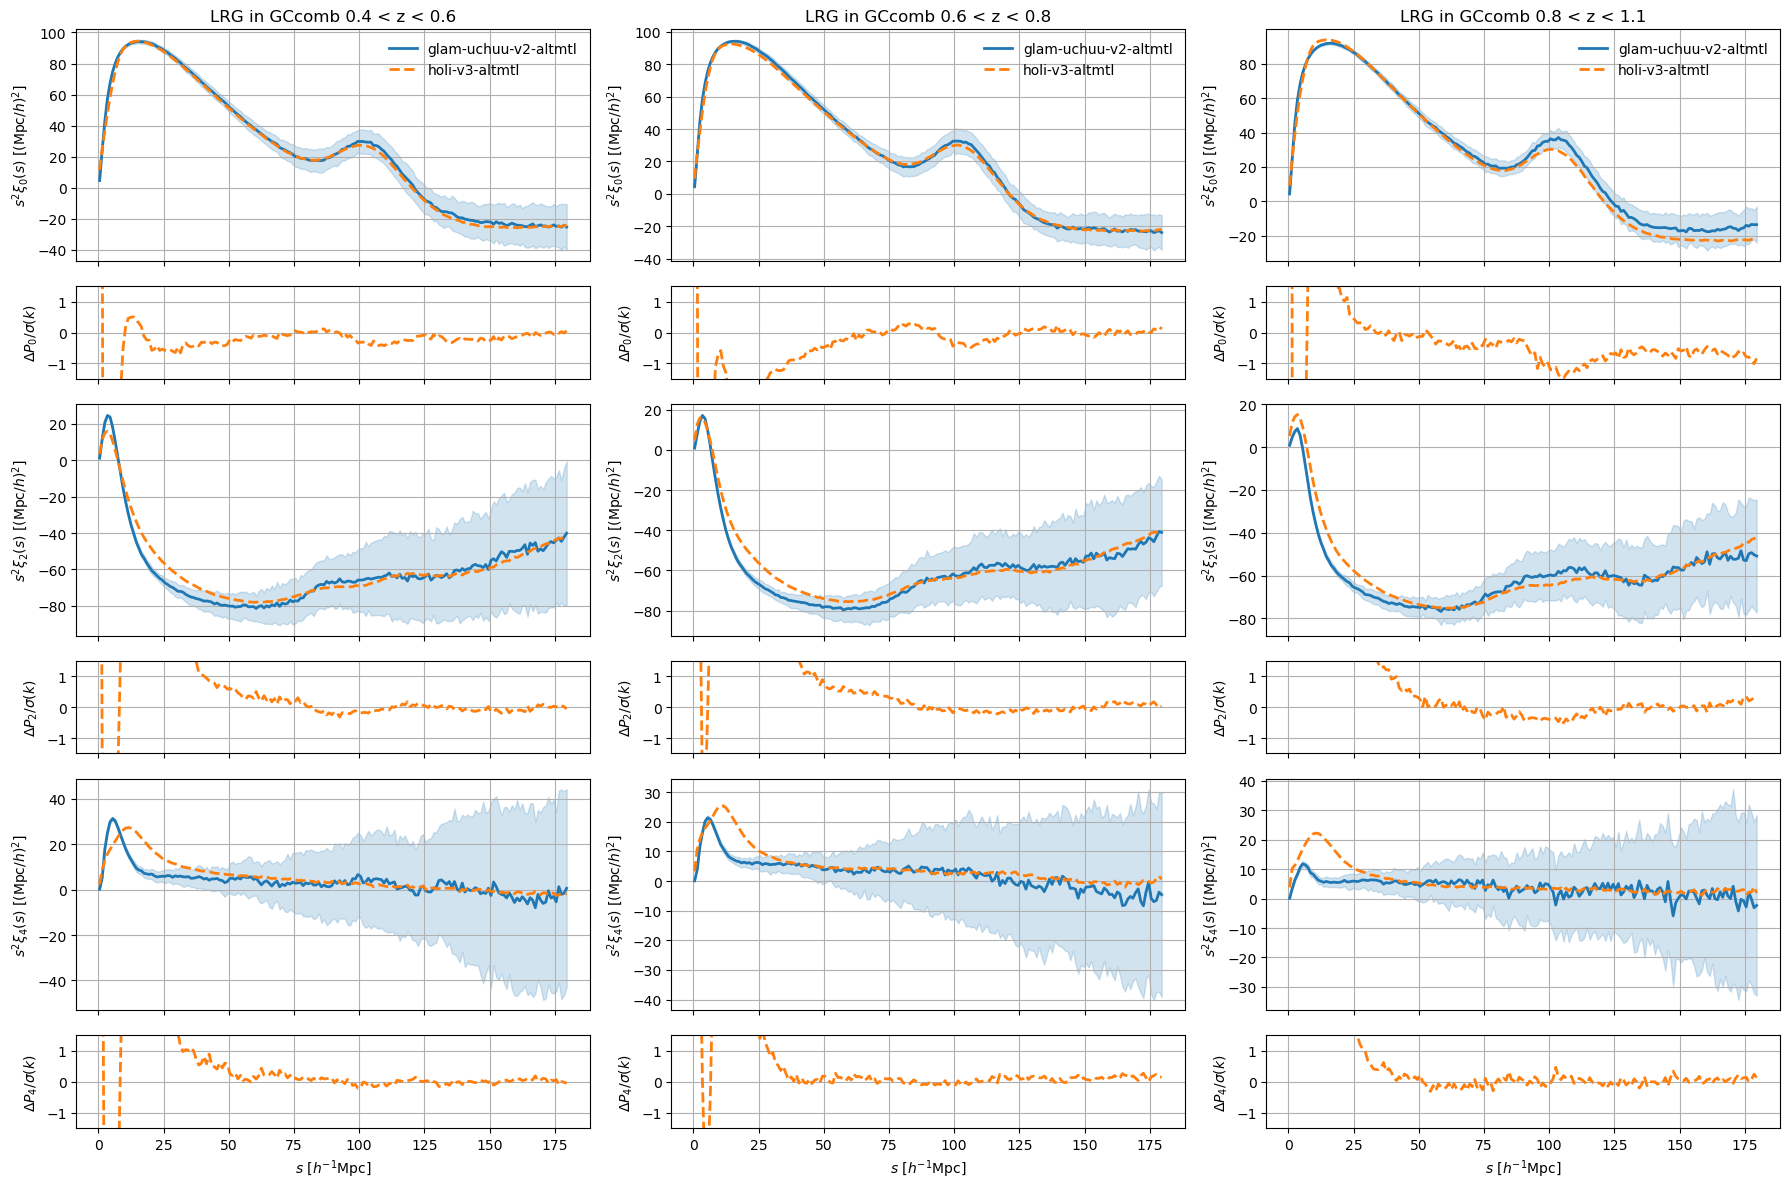

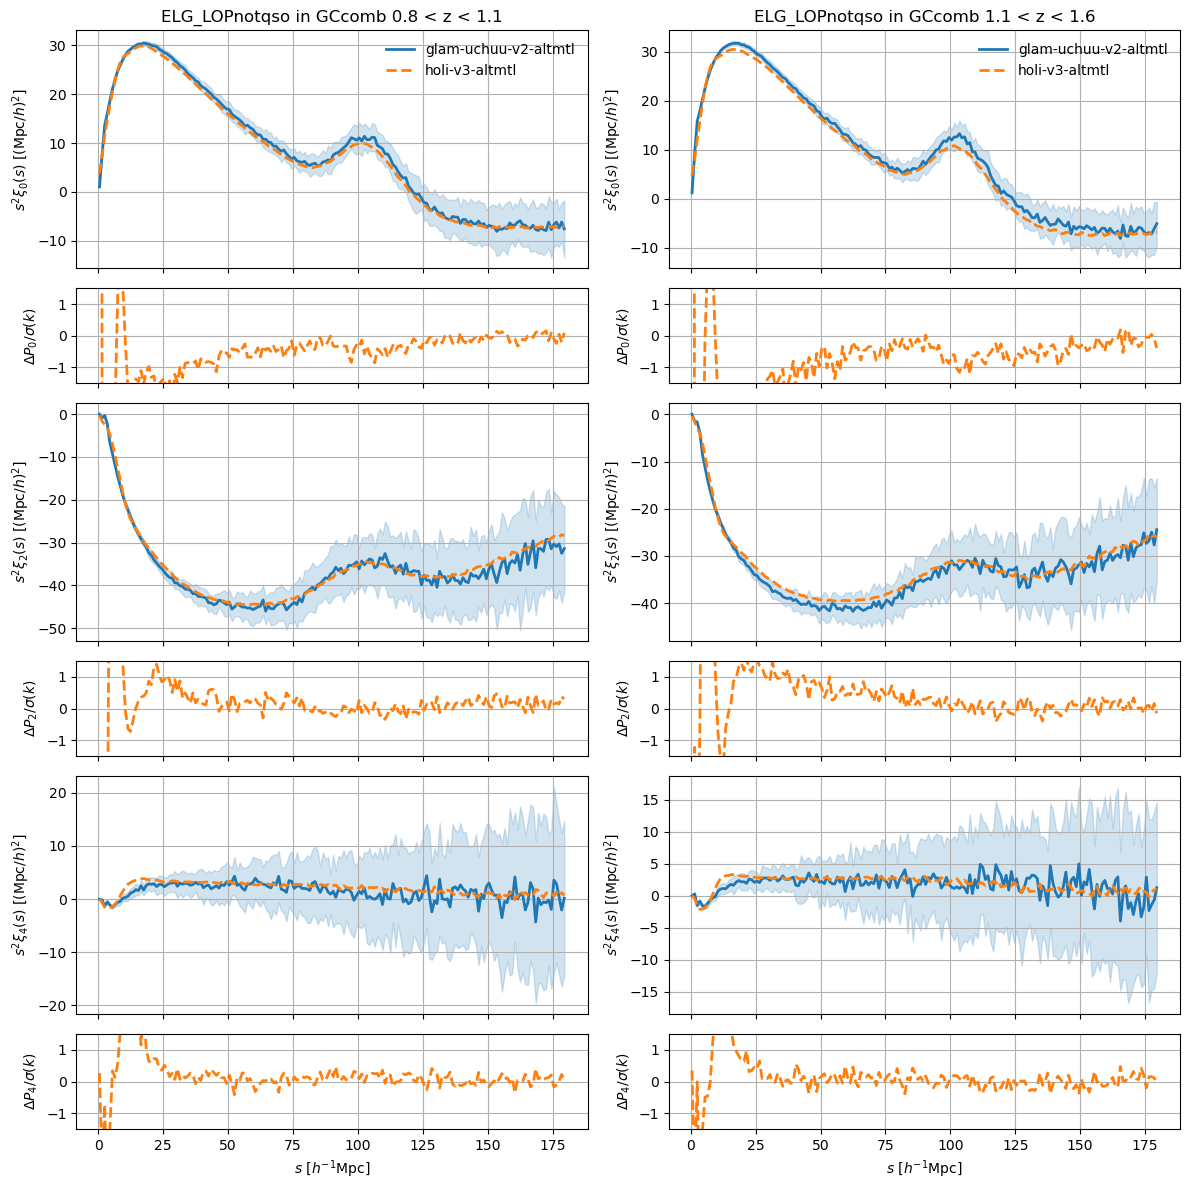

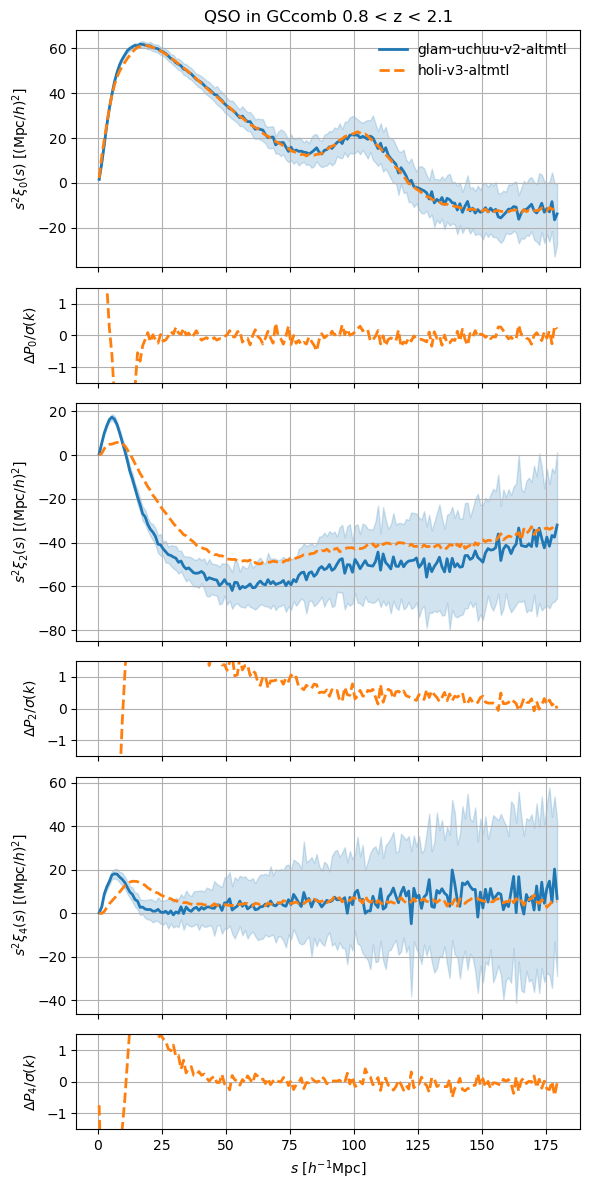

In [10]:
reference = 'glam-uchuu-v2-altmtl'
cases = {'glam-uchuu-v2-altmtl':   {'version': 'glam-uchuu-v2-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False},
         'holi-v3-altmtl':   {'version': 'holi-v3-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False}}

region = 'GCcomb'
tracers = ['LRG','ELG_LOPnotqso','QSO']
colors = dict(zip(cases, [f'C{i}' for i in range(len(cases))]))
linestyles = dict(zip(cases, ['-', '--','-.',':',':']))
plot_kws = dict(colors=colors,linestyles=linestyles,scaling=scaling,stats_dir=stats_dir,project=project)

for tracer in tracers:
    zranges = tools.propose_fiducial('zranges',tracer,analysis=analysis)
    nrows  = len(ells4xi) * 2
    ncols  = len(zranges)
    figure = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * len(ells4xi)), sharex='col', gridspec_kw={'height_ratios': [2.5, 1] * len(ells4xi)})
    for iz, zrange in enumerate(zranges):    
        plot_kws = plot_kws|dict(reference=reference, figure=figure, ax_col=iz, ells=ells4xi)
        plotting_tools.plot_stats('particle2_correlation', cases, tracer, zrange, region, **plot_kws)
    plt.tight_layout()
    basename = f'checks_xi_{tracer}_z{zrange[0]:.1f}-{zrange[1]:.1f}_{region}.{ext}'
    figure[0].savefig(plot_dir / basename, bbox_inches='tight', pad_inches=0.1, dpi=200)
    plt.show()

In [ ]:
# # version = 'glam-uchuu-v2-altmtl'
# version = 'holi-v3-altmtl'
# tracer = 'ELG_LOPnotqso'
# zrange = (0.8,1.1)
# region = 'SGC'
# kind = 'particle2_correlation'
# project = 'full_shape/base'
# # kind = 'mesh2_spectrum'
# fns = tools.get_stats_fn(stats_dir=stats_dir, project=project, kind=kind,
#                          version=version, tracer=tracer,
#                          zrange=zrange, region=region, weight='default-FKP', imock='*')
# print(len(fns))
# stats = list(map(types.read, fns))
# stats = [stat.project(ells=ells4xi) for stat in stats]
# types.mean(stats).plot(show=True)
# plt.show()

In [15]:
# check for available measurements
region = 'GAL060'
analysis = 'full_shape'
stats_dir = Path(str(tools.base_stats_dir).replace('global','dvs_ro'))
# project = f'{analysis}/base'
project = f'{analysis}/data_splits'
for tracer in ['LRG', 'ELG_LOPnotqso', 'QSO']:
    # for version in ['holi-v3-altmtl','glam-uchuu-v1-altmtl', 'glam-uchuu-v2-altmtl', 'abacus-2ndgen-dr2-complete','abacus-2ndgen-dr2-altmtl']:
    for version in ['glam-uchuu-v2-altmtl']:
        if 'ELG' in tracer:
            if 'complete' in version:
                tracer = 'ELG_LOP'
            else:
                tracer = 'ELG_LOPnotqso'
        for zrange in tools.propose_fiducial('zranges',tracer, analysis=analysis):
            fn = tools.get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh2_spectrum',
                                    version=version, tracer=tracer,
                                    zrange=zrange, region=region, weight='default-FKP', imock='*')
            print(tracer, version, zrange, 'mesh2_spectrum',len(fn))
        print()
    print()

LRG glam-uchuu-v2-altmtl (0.4, 0.6) mesh2_spectrum 50
LRG glam-uchuu-v2-altmtl (0.6, 0.8) mesh2_spectrum 50
LRG glam-uchuu-v2-altmtl (0.8, 1.1) mesh2_spectrum 50


ELG_LOPnotqso glam-uchuu-v2-altmtl (0.8, 1.1) mesh2_spectrum 50
ELG_LOPnotqso glam-uchuu-v2-altmtl (1.1, 1.6) mesh2_spectrum 50


QSO glam-uchuu-v2-altmtl (0.8, 2.1) mesh2_spectrum 50




In [11]:
# check for available measurements
region = 'GCcomb'
analysis = 'full_shape'
stats_dir = Path(str(tools.base_stats_dir).replace('global','dvs_ro'))
project = f'{analysis}/base'

versions = ['holi-v3-altmtl',
            'glam-uchuu-v2-altmtl', 
            'abacus-2ndgen-dr2-complete','abacus-2ndgen-dr2-altmtl', 'abacus-hf-dr2-v2-altmtl']
# versions = ['glam-uchuu-v2-altmtl']
for tracer in ['LRG', 'ELG_LOPnotqso', 'QSO']:
    for version in versions:
        if 'ELG' in tracer:
            if 'complete' in version:
                tracer = 'ELG_LOP'
            else:
                tracer = 'ELG_LOPnotqso'
        for zrange in tools.propose_fiducial('zranges',tracer, analysis=analysis):
            fn = tools.get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh2_spectrum',
                                    version=version, tracer=tracer,
                                    zrange=zrange, region=region, weight='default-FKP', imock='*')
            print(tracer, version, zrange, 'mesh2_spectrum',len(fn))
    
            fn = tools.get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh3_spectrum', basis='sugiyama-diagonal', 
                                    version=version, tracer=tracer,
                                    zrange=zrange, region=region, weight='default-FKP', imock='*')
            print(tracer, version, zrange, 'mesh3_spectrum-sugiyama-diagonal',len(fn))

            fn = tools.get_stats_fn(stats_dir=stats_dir, project=project, kind='particle2_correlation', 
                                    version=version, tracer=tracer,
                                    zrange=zrange, region=region, weight='default-FKP', imock='*')
            print(tracer, version, zrange, 'particle2_correlation_smu',len(fn))
        print()
    print()

LRG holi-v3-altmtl (0.4, 0.6) mesh2_spectrum 856
LRG holi-v3-altmtl (0.4, 0.6) mesh3_spectrum-sugiyama-diagonal 856
LRG holi-v3-altmtl (0.4, 0.6) particle2_correlation_smu 857
LRG holi-v3-altmtl (0.6, 0.8) mesh2_spectrum 856
LRG holi-v3-altmtl (0.6, 0.8) mesh3_spectrum-sugiyama-diagonal 856
LRG holi-v3-altmtl (0.6, 0.8) particle2_correlation_smu 857
LRG holi-v3-altmtl (0.8, 1.1) mesh2_spectrum 856
LRG holi-v3-altmtl (0.8, 1.1) mesh3_spectrum-sugiyama-diagonal 856
LRG holi-v3-altmtl (0.8, 1.1) particle2_correlation_smu 857

LRG glam-uchuu-v2-altmtl (0.4, 0.6) mesh2_spectrum 50
LRG glam-uchuu-v2-altmtl (0.4, 0.6) mesh3_spectrum-sugiyama-diagonal 50
LRG glam-uchuu-v2-altmtl (0.4, 0.6) particle2_correlation_smu 50
LRG glam-uchuu-v2-altmtl (0.6, 0.8) mesh2_spectrum 50
LRG glam-uchuu-v2-altmtl (0.6, 0.8) mesh3_spectrum-sugiyama-diagonal 50
LRG glam-uchuu-v2-altmtl (0.6, 0.8) particle2_correlation_smu 50
LRG glam-uchuu-v2-altmtl (0.8, 1.1) mesh2_spectrum 50
LRG glam-uchuu-v2-altmtl (0.8, 1.1)

# Check dubious realizations (Holi v3)

In [7]:
stats_dir = Path(str(tools.base_stats_dir).replace('global','dvs_ro'))
analysis  = 'full_shape'
project   = f'{analysis}/base'
version   = 'holi-v3-altmtl'

region = 'GCcomb'
tracer = 'QSO'
tracer = tools.get_full_tracer(tracer, version=version)
zrange = (0.8,2.1)

stats_kws = dict(stats_dir=stats_dir, project=project, kind='mesh3_spectrum', basis='sugiyama-diagonal', 
                 version=version, tracer=tracer, zrange=zrange, weight='default-FKP')
fns = tools.get_stats_fn(region=region, imock='*', **stats_kws)
print(tracer, version, zrange, 'mesh3_spectrum-sugiyama-diagonal',len(fns))

stats = list(map(types.read, fns))
mean  = types.mean(stats)
cov   = types.cov(stats).at.observable.match(mean)

QSO holi-v3-altmtl (0.8, 2.1) mesh3_spectrum-sugiyama-diagonal 997


141 / 997 are over threshold (>2.5e+06)


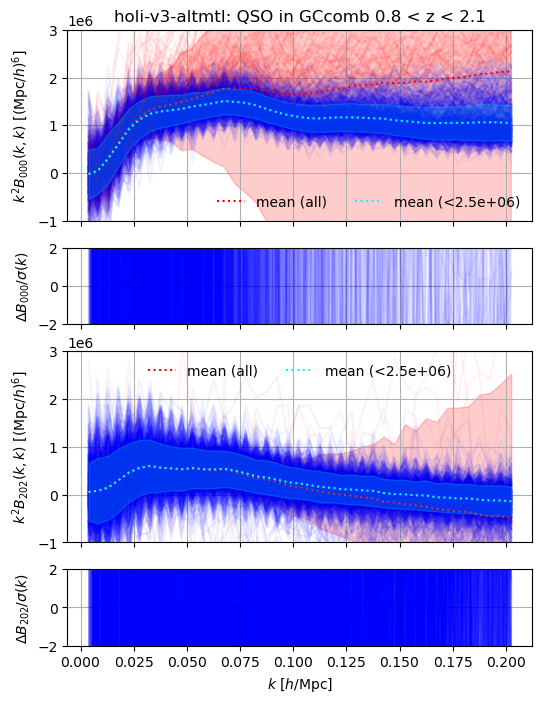

In [8]:
lw = 2
alpha=0.05
ylim=(-1e6, 3e6)
ylim_subpanel=(-2., 2.)
scaling = 'kpk'
k_exp = 1 if scaling == 'kpk' else 0
ells4bk=((0,0,0),(2,0,2))
zranges = [zrange]

# save mocks with power under some aribitrary threshold
threshold = 2.5e6
good_stats = [] 
bad_imocks = []
good_imocks = []
for i, stat in enumerate(stats):
    pole = stat.get(ells4bk[0])
    x = pole.coords('k')[..., 0]
    value = (x**2)**k_exp * pole.value().real
    # if value over threshold its bad, good otherwise
    if np.any(value > threshold):
        bad_imocks.append(int(str(fns[i]).split('/')[-2].replace('mock','')))
    else:
        good_imocks.append(int(str(fns[i]).split('/')[-2].replace('mock','')))
        good_stats.append(stat)
# check the good_imocks are truly good (since I am not sure if the indexing is conserved between fns and stats)
for imock in good_imocks:
    fn = tools.get_stats_fn(region=region, imock=imock, **stats_kws)
    stat = types.read(fn)
    pole = stat.get(ells4bk[0])
    x = pole.coords('k')[..., 0]
    value = (x**2)**k_exp * pole.value().real
    if np.any(value > threshold): 
        # if value over threshold its bad, good otherwise
        print(value)
        raise ValueError('Found bad mock within good mocks')
        
print(f'{len(stats)-len(good_stats)} / {len(stats)} are over threshold (>{threshold:1.1e})')
good_mean = types.mean(good_stats)
good_cov  = types.cov(good_stats).at.observable.match(good_mean)

nrows  = len(ells4bk) * 2
ncols  = len(zranges)
figure = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * len(ells4bk)), sharex='col', gridspec_kw={'height_ratios': [2.5, 1] * len(ells4bk)})
fig, axes = figure
ax_col = 0
if axes.ndim == 1:
    lax = axes
else:
    lax = axes[:, ax_col]
lax[0].set_title(f'{version}: {tracer} in {region} {zrange[0]:.1f} < z < {zrange[1]:.1f}')

for ill, ell in enumerate(ells4bk):
    ax = lax[2 * ill]
    if scaling == 'kpk':
        ax.set_ylabel(rf'$k^2 B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^6$]')
    if scaling == 'loglog':
        ax.set_ylabel(rf'$B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}}(k, k)$ [$(\mathrm{{Mpc}}/h)^4$]')
        ax.set_yscale('log')
        ax.set_xscale('log')

    #plot mean using all the mocks
    pole = mean.get(ell)
    x = pole.coords('k')[..., 0]
    value = (x**2)**k_exp * pole.value().real
    std = (x**2)**k_exp * cov.at.observable.get(ell).std().real
    ax.fill_between(x, value - std, value + std, color='r', alpha=0.2)
    ax.plot(x, value, color='r',zorder=4,linestyle=':',label='mean (all)')
       
    # good_stats = []  # save mocks with power under some aribitrary threshold
    ax.set_ylim(*ylim)
    for i, stat in enumerate(stats):
        if ell not in stat.ells: continue
        pole = stat.get(ell)
        x = pole.coords('k')[..., 0]
        value = (x**2)**k_exp * pole.value().real
        # if value over threshold paint red, blue otherwise
        if np.any(value > threshold):
            ax.plot(x, value, color='r', alpha=alpha)
        else:
            # good_stats.append(stat)
            ax.plot(x, value, color='b', alpha=alpha)

    # now plot mean and cov using mocks with power under some aribitrary threshold 
    pole = good_mean.get(ell)
    x = pole.coords('k')[..., 0]
    value = (x**2)**k_exp * pole.value().real
    std = (x**2)**k_exp * good_cov.at.observable.get(ell).std().real
    ax.fill_between(x, value - std, value + std, color='cyan', alpha=0.2,zorder=4)
    ax.plot(x, value, color='cyan',zorder=5,linestyle=':',label=f'mean (<{threshold:1.1e})')

    ax.legend(frameon=False, ncol=2)
        
    ax.grid(True)
    ax = lax[2 * ill + 1]
    ax.set_ylabel(rf'$\Delta B_{{{ell[0]:d}{ell[1]:d}{ell[2]:d}}} / \sigma(k)$')
    ax.grid(True)
    ax.set_ylim(*ylim_subpanel)
    for i, stat in enumerate(stats):
        pole = stat.get(ell)
        x = pole.coords('k')[..., 0]
        ax.plot(x, (pole.value() - mean.get(ell).value()).real / std, color='b', alpha=alpha)
lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
figure[0].savefig(plot_dir / 'checks_bk_QSO.png', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()

In [9]:
# save .txt with the bad mocks
print(bad_imocks)
np.savetxt('../helper_scripts/dubious_holi-v3-altmtl.txt',bad_imocks,fmt='%i')

[2, 5, 8, 9, 17, 26, 34, 47, 50, 51, 54, 62, 66, 71, 73, 76, 78, 97, 106, 114, 140, 142, 146, 148, 149, 152, 155, 163, 176, 184, 191, 194, 202, 208, 234, 248, 260, 264, 269, 296, 298, 299, 320, 326, 330, 331, 337, 349, 358, 371, 376, 378, 379, 384, 389, 391, 392, 408, 409, 423, 425, 429, 430, 437, 438, 444, 447, 448, 452, 458, 473, 477, 487, 512, 515, 522, 530, 531, 532, 542, 553, 562, 566, 571, 591, 595, 597, 609, 611, 623, 624, 625, 634, 637, 638, 643, 644, 649, 655, 657, 671, 679, 682, 690, 693, 698, 699, 704, 707, 713, 716, 718, 727, 741, 766, 770, 776, 784, 788, 802, 815, 824, 835, 846, 850, 864, 867, 879, 882, 893, 903, 919, 923, 928, 932, 951, 953, 971, 977, 982, 983]


In [19]:
# now using the good_imocks list idendified above
stats_kws = dict(stats_dir=stats_dir, project=project, kind='mesh2_spectrum', 
                 version=version, tracer=tracer, zrange=zrange, weight='default-FKP')

fns = tools.get_stats_fn(region=region, imock='*', **stats_kws)
print(tracer, version, zrange, 'mesh2_spectrum',len(fns))
stats = list(map(types.read, fns))
mean  = types.mean(stats)
cov   = types.cov(stats).at.observable.match(mean)

fns = [tools.get_stats_fn(region=region, imock=imock, **stats_kws) for imock in good_imocks]
print(tracer, version, zrange, 'mesh2_spectrum',len(fns))
good_stats = list(map(types.read, fns))
good_mean  = types.mean(good_stats)
good_cov   = types.cov(good_stats).at.observable.match(good_mean)

QSO holi-v3-altmtl (0.8, 2.1) mesh2_spectrum 997
QSO holi-v3-altmtl (0.8, 2.1) mesh2_spectrum 856


In [20]:
fns = [tools.get_stats_fn(region=region, imock=imock, **stats_kws) for imock in bad_imocks]
print(tracer, version, zrange, 'mesh2_spectrum',len(fns))
bad_stats = list(map(types.read, fns))

QSO holi-v3-altmtl (0.8, 2.1) mesh2_spectrum 141


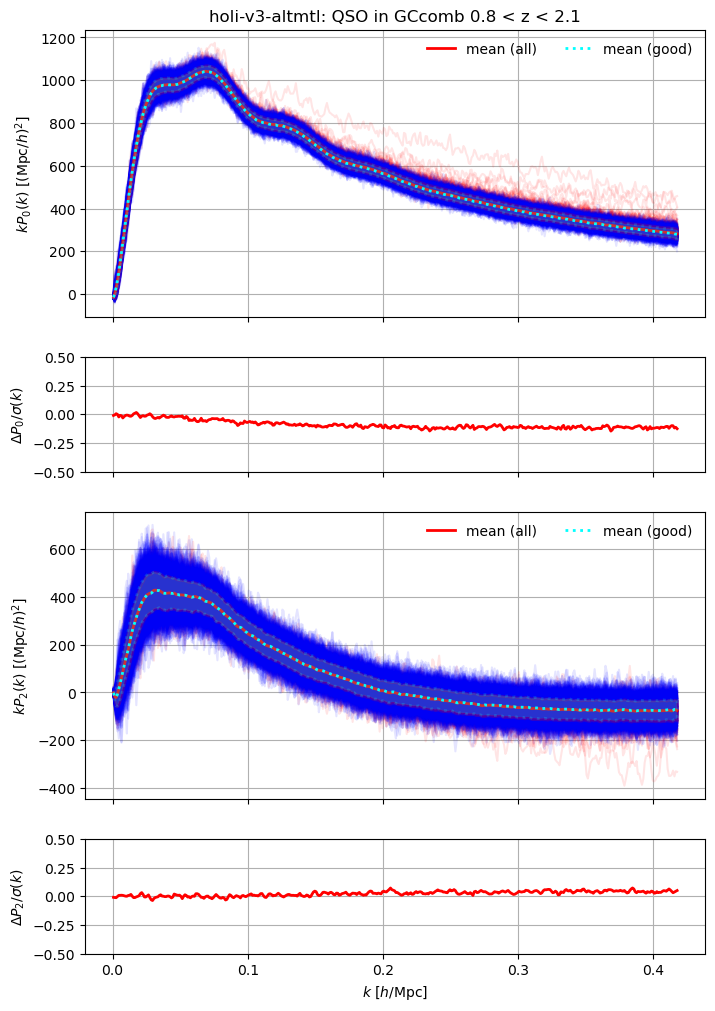

In [40]:
lw = 2
alpha=0.1
ylim=(-1e6, 3e6)
ylim_subpanel=(-.5, .5)
scaling = 'kpk'
k_exp = 1 if scaling == 'kpk' else 0
ells4pk=(0,2)
zranges = [zrange]

nrows  = len(ells4pk) * 2
ncols  = len(zranges)
figure = plt.subplots(nrows, ncols, figsize=(8 * ncols, 6 * len(ells4pk)), sharex='col', 
                      gridspec_kw={'height_ratios': [2.5, 1] * len(ells4pk)})
# figure = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * len(ells4pk)), sharex='col')
fig, axes = figure
ax_col = 0
if axes.ndim == 1:
    lax = axes
else:
    lax = axes[:, ax_col]
lax[0].set_title(f'{version}: {tracer} in {region} {zrange[0]:.1f} < z < {zrange[1]:.1f}')

for ill, ell in enumerate(ells4pk):
    ax = lax[2 * ill]
    # ax = lax[ill]
    if scaling == 'kpk':
        ax.set_ylabel(rf'$k P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
    if scaling == 'loglog':
        ax.set_ylabel(rf'$P_{ell:d}(k)$ [$(\mathrm{{Mpc}}/h)^3$]')
        ax.set_yscale('log')
        ax.set_xscale('log')
       
    # ax.set_ylim(*ylim)
    for i, stat in enumerate(bad_stats):
        if ell not in stat.ells: continue
        pole = stat.get(ell)
        x = pole.coords('k')
        value = x**k_exp * pole.value().real
        ax.plot(x, value, color='r', alpha=alpha)
    
    for i, stat in enumerate(good_stats):
        if ell not in stat.ells: continue
        pole = stat.get(ell)
        x = pole.coords('k')
        value = x**k_exp * pole.value().real
        ax.plot(x, value, color='b', alpha=alpha)

    #plot mean using all the mocks
    pole = bad_pole = mean.get(ell)
    x = pole.coords('k')
    value = x**k_exp * pole.value().real
    std = x**k_exp * cov.at.observable.get(ell).std().real
    ax.fill_between(x, value - std, value + std, color='r', alpha=0.2,lw=lw, zorder=4)
    ax.plot(x, value, color='r',zorder=4,linestyle='-',label='mean (all)',lw=lw)
    
    # now plot mean and cov using mocks with power under some aribitrary threshold 
    pole = good_pole = good_mean.get(ell)
    x = pole.coords('k')
    value = x**k_exp * pole.value().real
    std = x**k_exp * good_cov.at.observable.get(ell).std().real
    ax.fill_between(x, value - std, value + std, color='cyan', linestyle=':',lw=lw, alpha=0.2,zorder=5)
    ax.plot(x, value, color='cyan',zorder=5,linestyle=':',label=f'mean (good)',lw=lw)

    ax.legend(frameon=False, ncol=2)

    ax.grid(True)
    ax = lax[2 * ill + 1]
    ax.set_ylabel(rf'$\Delta P_{ell:d} / \sigma(k)$')
    ax.grid(True)
    ax.set_ylim(*ylim_subpanel)
    std = cov.at.observable.get(ell).std().real
    ax.plot(x, (good_pole.value().real - bad_pole.value().real) / std, color='r', ls='-', lw=lw)
    # std = good_cov.at.observable.get(ell).std().real
    # ax.plot(x, (good_pole.value().real - bad_pole.value().real) / std, color='cyan', ls=':', lw=lw)
    
lax[-1].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
figure[0].savefig(plot_dir / 'checks_pk_QSO.png', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()

In [18]:
mean

Mesh3SpectrumPoles(labels=[{'ells': (0, 0, 0)}, {'ells': (2, 0, 2)}], size=82)

In [8]:
#!ls -l /global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base/holi-v3-altmtl/mock10/mesh3_spectrum_sugiyama-diagonal_poles_LRG_z0.8-1.1*

In [9]:
# # region = 'GCcomb'
# region = 'GCcomb'
# tracer = 'ELG_LOPnotqso'
# version = 'holi-v3-altmtl'
# versions = {'holi-v3-altmtl':   {'version': 'holi-v3-altmtl', 'weight': 'default-FKP', 'extra': '', 'cut': False, 'auw': False}}

# if 'ELG' in tracer:
#     if 'complete' in version:
#         tracer = 'ELG_LOP'
#     else:
#         tracer = 'ELG_LOPnotqso'
# for zrange in tools.propose_fiducial('zranges',tracer, analysis=analysis)[-1:]:
#     print(zrange)
#     # fig = plt.gcf()
#     fns = tools.get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh3_spectrum', basis='sugiyama-diagonal',
#                             version=version, tracer=tracer,
#                             zrange=zrange, region=region, weight='default-FKP', imock='*')
#     # stats = list(map(types.read, fns))
#     # spectrum = types.mean(stats).select(k=slice(0, None, 1))
#     # print(spectrum.get(ells4bk[0]).value().real)
#     for fn in fns:
#         spectrum = types.read(fn)
#         print(fn,spectrum.get(ells4bk[0]).value().real)
#     # spectrum.plot(fig=fig)
#     # plt.legend()
#     # plt.show()

In [10]:
# tracer = 'ELG_LOPnotqso'
# version = 'abacus-2ndgen-complete'
# if 'ELG' in tracer:
#     if 'complete' in version:
#         tracer = 'ELG_LOP'
#     else:
#         tracer = 'ELG_LOPnotqso'
# for zrange in tools.propose_fiducial('zranges',tracer, analysis=analysis):
#     fig = plt.gcf()
#     fns = tools.get_stats_fn(stats_dir=stats_dir, project=project, kind='mesh2_spectrum',
#                         version=version, tracer=tracer,
#                         zrange=zrange, region='GCcomb', weight='default-FKP', imock='*')
#     for fn in fns:
#         spectrum = types.read(fn)
#         spectrum.plot(fig=fig)
#     plt.show()